In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None) #this code allows for all columns to be displayed

The structure of the data is rectangular as it represents row and columns.

For The granularity,  each data point represents a single cause of death per gender of each race/ethnicity data therefore it has coarse level of granularity.

Since I am interested in the causes of death in New York City, this datset covers the right amount of information.

The data is from 2007 to 2021. Therefore the temporality is each year from 2007 to 2021.

There are some faithfulness problems because there is missing data.

In [ ]:
causes = pd.read_csv("https://raw.githubusercontent.com/mducasse714/mat301-datasets/refs/heads/main/New_York_City_Leading_Causes_of_Death_20260223.csv", na_values = ["."])
causes.head(20)

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
0,2021,Mental and Behavioral Disorders due to Acciden...,Male,Other Race/ Ethnicity,9.0,NaN,NaN
1,2021,All Other Causes,Female,Not Stated/Unknown,102.0,NaN,NaN
2,2021,Chronic Liver Diseases and Cirrhosis,Male,Not Stated/Unknown,16.0,NaN,NaN
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
4,2021,Influenza (Flu) and Pneumonia (J09-J18),Male,Not Stated/Unknown,16.0,NaN,NaN
5,2021,Influenza (Flu) and Pneumonia (J09-J18),Female,Other Race/ Ethnicity,4.0,NaN,NaN
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
9,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Not Stated/Unknown,113.0,NaN,NaN


In [ ]:
causes['Year'].unique()

array([2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011,
       2010, 2009, 2008, 2007])

In [ ]:
causes.columns

Index(['Year', 'Leading Cause', 'Sex', 'Race Ethnicity', 'Deaths',
       'Death Rate', 'Age Adjusted Death Rate'],
      dtype='object')

#Cleaning data

removing duplicates,missing rows, Changing the text in columns

In [ ]:
dup_filter = causes.duplicated() # 2 duplicated rows and removed them
causes[dup_filter]

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
314,2019,Alzheimer's Disease (G30),Female,Other Race/ Ethnicity,3.0,NaN,NaN
382,2019,Mental and Behavioral Disorders due to Acciden...,Male,Other Race/ Ethnicity,5.0,NaN,NaN


In [ ]:
causes = causes.drop_duplicates()
causes

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
0,2021,Mental and Behavioral Disorders due to Acciden...,Male,Other Race/ Ethnicity,9.0,NaN,NaN
1,2021,All Other Causes,Female,Not Stated/Unknown,102.0,NaN,NaN
2,2021,Chronic Liver Diseases and Cirrhosis,Male,Not Stated/Unknown,16.0,NaN,NaN
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
4,2021,Influenza (Flu) and Pneumonia (J09-J18),Male,Not Stated/Unknown,16.0,NaN,NaN
...,...,...,...,...,...,...,...
2097,2007,Diabetes Mellitus (E10-E14),F,White Non-Hispanic,231.0,16.1,9.8
2098,2007,Influenza (Flu) and Pneumonia (J09-J18),F,White Non-Hispanic,659.0,45.9,23.2
2099,2007,Influenza (Flu) and Pneumonia (J09-J18),F,Not Stated/Unknown,NaN,NaN,NaN
2100,2007,Cerebrovascular Disease (Stroke: I60-I69),M,Hispanic,126.0,11.6,20.0


In [ ]:
len(causes)

2100

In [ ]:
causes.describe()

,Year,Deaths,Death Rate,Age Adjusted Death Rate
count,2100.000000,1962.000000,1373.000000,1373.000000
mean,2014.084762,429.689602,56.258163,53.607305
std,4.333133,827.894141,75.598398,68.109884
min,2007.000000,1.000000,2.400000,2.500000
25%,2010.000000,25.000000,12.843000,12.338107
50%,2014.000000,141.000000,20.100000,19.800000
75%,2018.000000,317.750000,78.900000,81.500000
max,2021.000000,7050.000000,491.400000,414.594473


In [ ]:
causes.describe(include = ["O"])

,Leading Cause,Sex,Race Ethnicity
count,2100,2100,2100
unique,42,4,8
top,All Other Causes,F,Other Race/ Ethnicity
freq,182,622,411


In [ ]:
causes.isnull().sum()

,0
Year,0
Leading Cause,0
Sex,0
Race Ethnicity,0
Deaths,138
Death Rate,727
Age Adjusted Death Rate,727


In [ ]:
causes_cleaned = causes.dropna()
causes_cleaned

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,Hispanic,233.0,18.4,17.8
...,...,...,...,...,...,...,...
2095,2007,Human Immunodeficiency Virus Disease (HIV: B20...,M,Black Non-Hispanic,377.0,44.2,44.2
2096,2007,Essential Hypertension and Renal Diseases (I10...,F,Black Non-Hispanic,166.0,15.8,15.0
2097,2007,Diabetes Mellitus (E10-E14),F,White Non-Hispanic,231.0,16.1,9.8
2098,2007,Influenza (Flu) and Pneumonia (J09-J18),F,White Non-Hispanic,659.0,45.9,23.2


In [ ]:
causes_cleaned.dtypes

,0
Year,int64
Leading Cause,object
Sex,object
Race Ethnicity,object
Deaths,float64
Death Rate,float64
Age Adjusted Death Rate,float64


In [ ]:
causes_cleaned.describe() #numerical data types

,Year,Deaths,Death Rate,Age Adjusted Death Rate
count,1373.000000,1373.000000,1373.000000,1373.000000
mean,2014.139111,602.957757,56.258163,53.607305
std,4.332098,937.479492,75.598398,68.109884
min,2007.000000,5.000000,2.400000,2.500000
25%,2010.000000,110.000000,12.843000,12.338107
50%,2014.000000,220.000000,20.100000,19.800000
75%,2018.000000,529.000000,78.900000,81.500000
max,2021.000000,7050.000000,491.400000,414.594473


In [ ]:
causes_cleaned.describe(include = ["O"]) #for nonintegers or non-numbers

,Leading Cause,Sex,Race Ethnicity
count,1373,1373,1373
unique,28,4,7
top,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",M,Asian and Pacific Islander
freq,124,412,333


In [ ]:
causes_cleaned['Sex'].unique()

array(['Female', 'Male', 'F', 'M'], dtype=object)

In [ ]:
gender_map = {"M":"Male", "F":"Female", "Male":"Male", "Female":"Female"} #dictionary doing a few change
causes_cleaned["Sex"] = causes_cleaned["Sex"].map(gender_map)
causes_cleaned
causes_cleaned["Sex"] = causes_cleaned["Sex"].map(gender_map)
causes_cleaned

/tmp/ipykernel_581/3086009923.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  causes_cleaned["Sex"] = causes_cleaned["Sex"].map(gender_map)
/tmp/ipykernel_581/3086009923.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  causes_cleaned["Sex"] = causes_cleaned["Sex"].map(gender_map)


,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,Hispanic,233.0,18.4,17.8
...,...,...,...,...,...,...,...
2095,2007,Human Immunodeficiency Virus Disease (HIV: B20...,Male,Black Non-Hispanic,377.0,44.2,44.2
2096,2007,Essential Hypertension and Renal Diseases (I10...,Female,Black Non-Hispanic,166.0,15.8,15.0
2097,2007,Diabetes Mellitus (E10-E14),Female,White Non-Hispanic,231.0,16.1,9.8
2098,2007,Influenza (Flu) and Pneumonia (J09-J18),Female,White Non-Hispanic,659.0,45.9,23.2


In [ ]:
#causes_cleaned["Deaths"] = causes_cleaned["Deaths"].astype(float)
#causes_cleaned["Death Rate", "Age Adjusted Death Rate"] = causes_cleaned["Death Rate", "Age Adjusted Death Rate"].astype(float)

# Single variable distribution plots


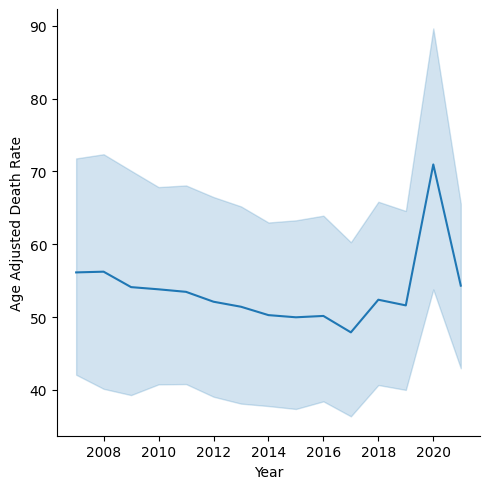

In [ ]:
#What is the trend of Age Adjusted Death Rate during this time period?
sns.relplot(x = "Year", y = "Age Adjusted Death Rate", kind = "line", data = causes_cleaned)

<Axes: >

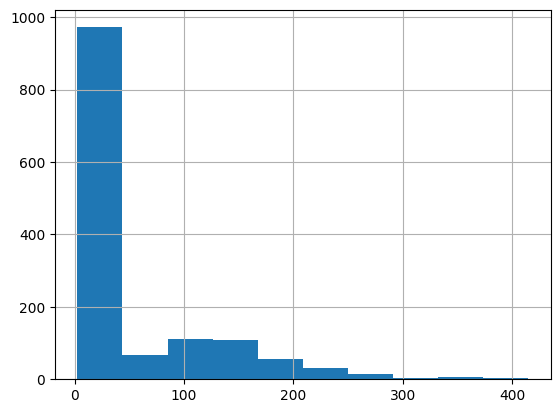

In [ ]:
#histogram for Age Adjusted Death Rate
causes_cleaned['Age Adjusted Death Rate'].hist(bins = 10)

<Axes: >

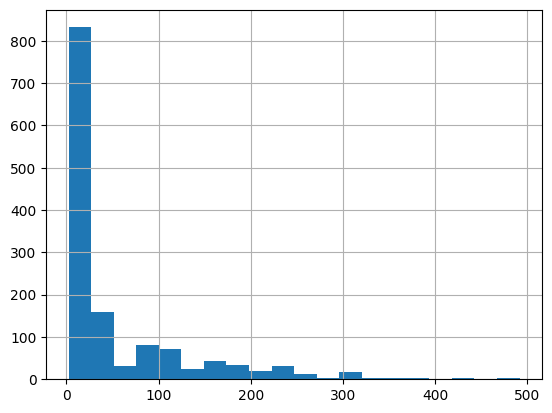

In [ ]:
causes_cleaned['Death Rate'].hist(bins = 20)

In [ ]:
#WHAT IS THE MAJOR CAUSE OF DEATH AMONG HISPANIC FEMALES
hispanic = causes_cleaned["Race Ethnicity"] == "Hispanic"
female = causes_cleaned["Sex"] == "Female"
hispanic_f = causes_cleaned[hispanic & female]
hispanic_f

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,Hispanic,233.0,18.4,17.8
...,...,...,...,...,...,...,...
2078,2007,All Other Causes,Female,Hispanic,820.0,70.2,85.6
2081,2007,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,164.0,14.0,18.3
2082,2007,Essential Hypertension and Renal Diseases (I10...,Female,Hispanic,78.0,6.7,8.9
2085,2007,Diabetes Mellitus (E10-E14),Female,Hispanic,205.0,17.6,22.6


In [ ]:
#how many hispanic women died due to Diseases of Heart (I00-I09, I11, I13, I20-I51) during this period
heart_disease = hispanic_f["Leading Cause"] == "Diseases of Heart (I00-I09, I11, I13, I20-I51)"
hispanic_heart_disease = hispanic_f[heart_disease]
hispanic_heart_disease

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.000000,95.500000
202,2020,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1850.0,142.200000,127.600000
402,2019,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1574.0,125.735722,111.735337
539,2018,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1493.0,118.033000,109.083000
710,2017,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1437.0,110.817637,106.281597
826,2016,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1485.0,115.897012,120.315311
879,2015,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1361.0,106.484024,113.376700
1025,2014,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1230.0,97.100000,106.700000
1226,2013,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1261.0,101.000000,113.600000
1346,2012,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1263.0,102.000000,118.400000


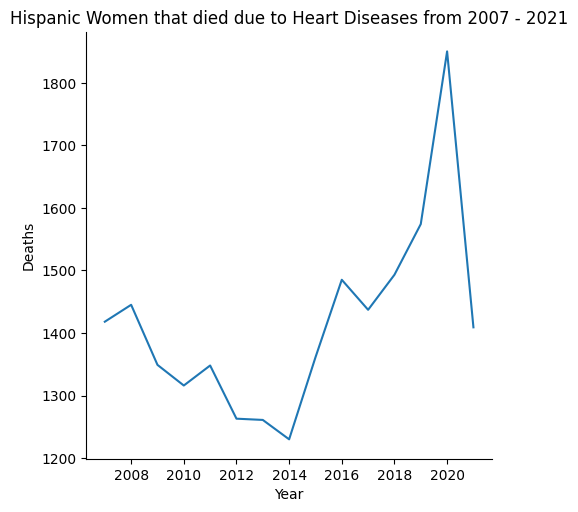

In [ ]:
sns.relplot(x = "Year", y = "Deaths", kind = "line", data = hispanic_heart_disease)
plt.title("Hispanic Women that died due to Heart Diseases from 2007 - 2021")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.show()
#What year did hispanic females have death amout due to heart diseases
#During 2020 women had the highest deaths related to heart diseases.  1,856 died in 2020 of heart diseases.


#  Multiple variable plots


In [ ]:
causes_cleaned

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409.0,111.0,95.5
6,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Hispanic,1157.0,91.2,80.8
7,2021,Covid-19,Female,Hispanic,966.0,76.1,66.8
8,2021,Cerebrovascular Disease (Stroke: I60-I69),Female,Hispanic,265.0,20.9,18.0
11,2021,Mental and Behavioral Disorders due to Acciden...,Female,Hispanic,233.0,18.4,17.8
...,...,...,...,...,...,...,...
2095,2007,Human Immunodeficiency Virus Disease (HIV: B20...,Male,Black Non-Hispanic,377.0,44.2,44.2
2096,2007,Essential Hypertension and Renal Diseases (I10...,Female,Black Non-Hispanic,166.0,15.8,15.0
2097,2007,Diabetes Mellitus (E10-E14),Female,White Non-Hispanic,231.0,16.1,9.8
2098,2007,Influenza (Flu) and Pneumonia (J09-J18),Female,White Non-Hispanic,659.0,45.9,23.2


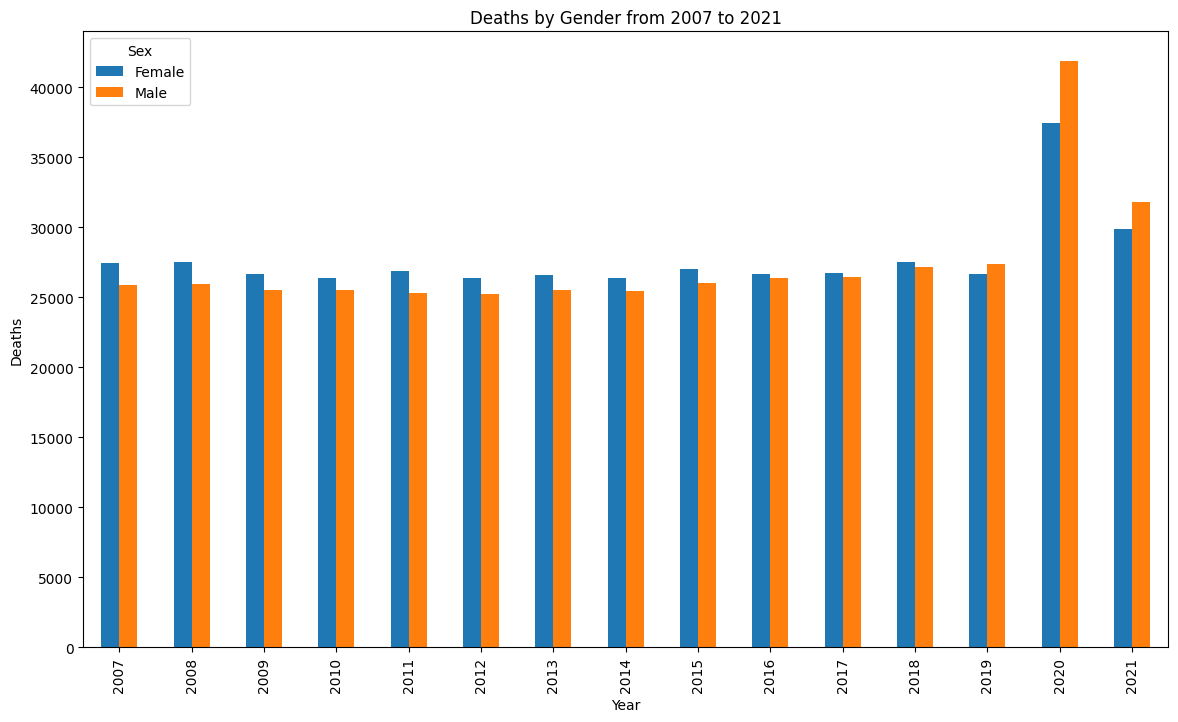

In [ ]:
gender_year_death = causes_cleaned.groupby(["Year","Sex"])["Deaths"].sum().unstack()
gender_year_death.plot(kind = 'bar', figsize=(14,8))
plt.title("Deaths by Gender from 2007 to 2021")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.show()
#What years saw the most death between males and females


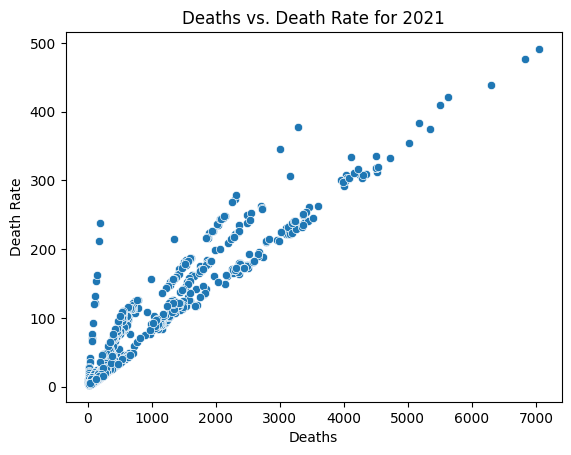

In [ ]:
sns.scatterplot(x='Deaths', y='Death Rate', data=causes_cleaned)
plt.xlabel('Deaths')
plt.ylabel('Death Rate')
plt.title('Deaths vs. Death Rate for 2021')
plt.show()